In [2]:
from hossam import load_data
from helpers import *
from pandas import DataFrame
import pandas as pd
from IPython.display import display, Markdown

import os               # 파일 및 디렉토리 경로를 처리하는 파이썬 내장 모듈
import joblib           # 학습된 모델을 파일로 저장하고 복원하는 직렬화 모듈
import numpy as np      # 수치계산을 위한 파이썬 내장 모듈
import glob as gl       # 파일 목록을 리스트로 반환하는 파이썬 내장 모듈
import datetime as dt   # 날짜 및 시간 처리를 위한 파이썬 내장 모듈

# 훈련, 검증 데이터 분리 함수
from sklearn.model_selection import train_test_split

# 성능평가 지표 계산 함수
from sklearn.metrics import (
    r2_score,                           # 결정계수 (R2)
    mean_absolute_error,                # 평균절대오차 (MAE)
    mean_squared_error,                 # 평균제곱오차 (MSE)
    mean_squared_log_error,             # 평균제곱로그오차 (MSLE)
    mean_absolute_percentage_error      # 평균절대백분율오차 (MAPE)
)

# 선형 계열 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# 트리계열 모델
from sklearn.tree import DecisionTreeRegressor

# 앙상블 모델
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.25

⚠️  'hossam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.25, 최신 버전: 0.5.34)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade hossam



In [3]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = pd.read_excel("local_features_log_labeled.xlsx")
df = my_qtcheck.set_type(origin, as_category=["spatial_cluster", "년도", "기준월"])

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   총인구수              6240 non-null   float64 
 1   만명당_가맹점수          6240 non-null   float64 
 2   spatial_cluster   6240 non-null   category
 3   기준월               6240 non-null   category
 4   년도                6240 non-null   category
 5   만명당_가맹점수_소매       6240 non-null   float64 
 6   만명당_가맹점수_음식       6240 non-null   float64 
 7   만명당_가맹점수_부동산      6240 non-null   float64 
 8   만명당_가맹점수_과학·기술    6240 non-null   float64 
 9   만명당_가맹점수_시설관리·임대  6240 non-null   float64 
 10  만명당_가맹점수_보건의료     6240 non-null   float64 
 11  만명당_가맹점수_예술·스포츠   6240 non-null   float64 
 12  만명당_가맹점수_수리·개인    6240 non-null   float64 
 13  만명당_가맹점수_기타       6240 non-null   float64 
 14  가맹점당_월유동인구        6240 non-null   float64 
 15  매출금액              6240 non-null   float64 
dtypes: category(3), float64(13)
memory 

## 4. 데이터에서 독립변수와 종속변수 분리
### 머신러닝에서는 독립변수를 feature, 종속변수를 target으로 명명한다.

In [3]:
feature = df.drop(columns=["매출금액"])
target = df["매출금액"]
feature.shape, target.shape

((6240, 15), (6240,))

## 5. 훈련, 검증 데이터 분리

In [4]:
# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4992, 15), (1248, 15), (4992,), (1248,))

## 6. 학습을 완료한 모델이 저장될 폴더

In [5]:
project_name = "local"
base_dir = f"{project_name}/baseline"

if not os.path.exists(base_dir):
    os.makedirs(base_dir)

작업 폴더: local\baseline
학습 완료 [ 1/11] : linear
학습 완료 [ 2/11] : ridge
학습 완료 [ 3/11] : lasso
학습 완료 [ 4/11] : elasticnet
학습 완료 [ 5/11] : kneighbors
학습 완료 [ 6/11] : svr
학습 완료 [ 7/11] : decisiontree
학습 완료 [ 8/11] : randomforest
학습 완료 [ 9/11] : xgb
학습 완료 [10/11] : lgbm
학습 완료 [11/11] : catboost


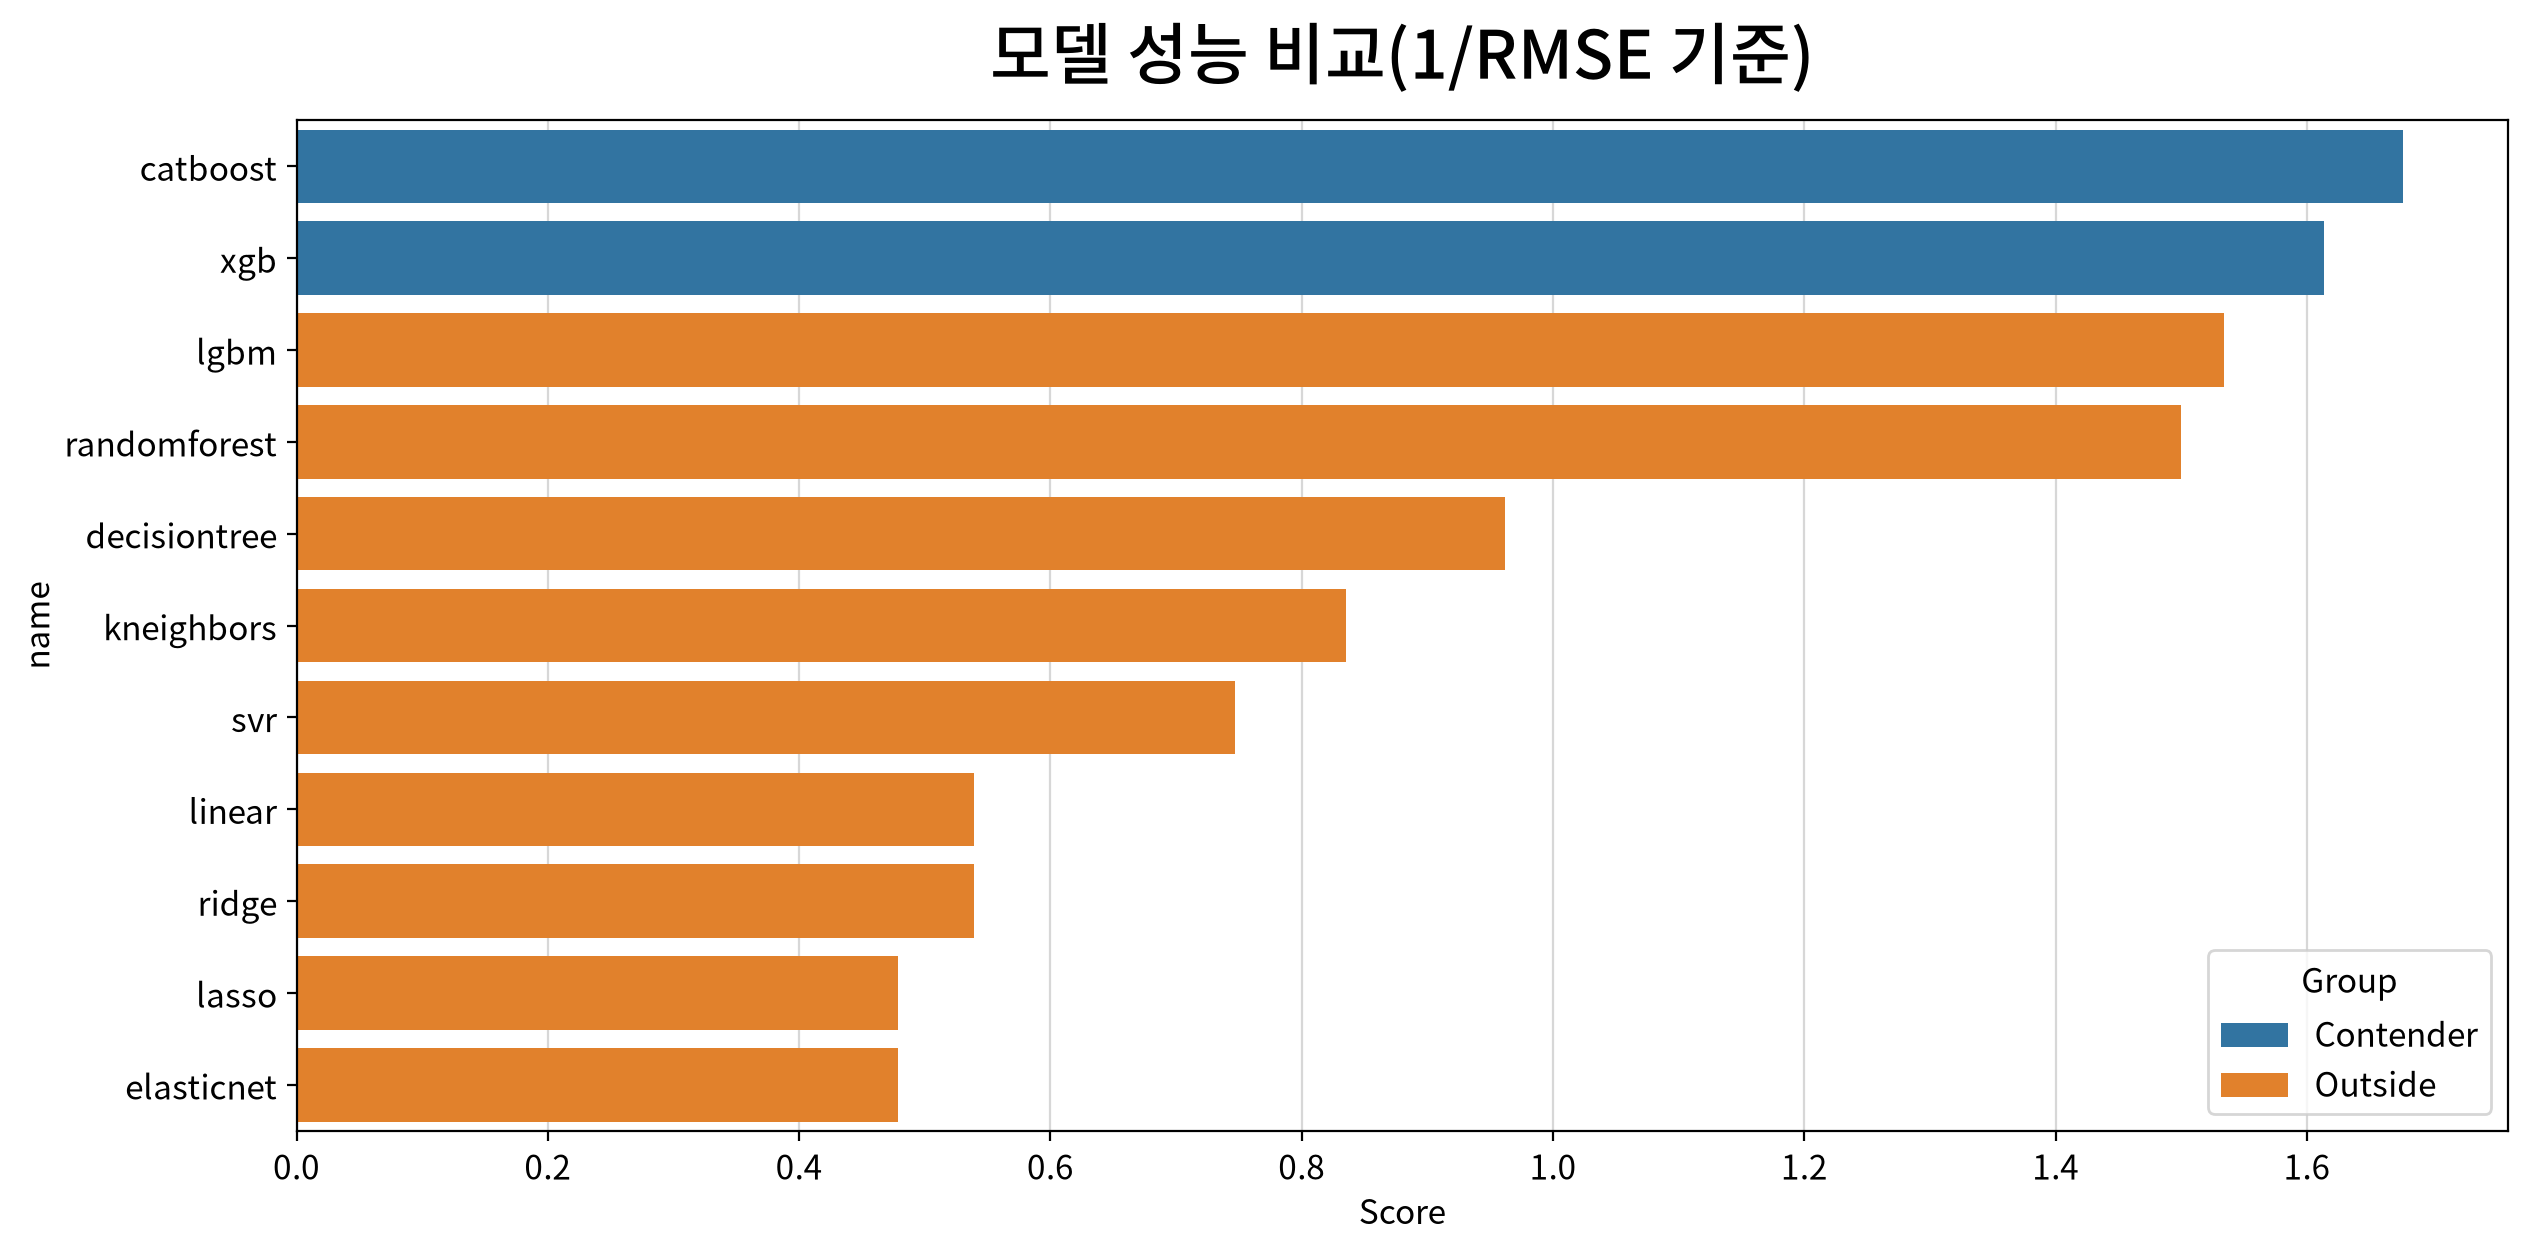


모델 11개 학습·저장 완료 → local\baseline


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
catboost,1,Contender,CatBoostRegressor,0.919,0.411,0.356,0.597,0.043,0.031,-0.005,0.000,1.676
xgb,2,Contender,XGBRegressor,0.912,0.413,0.384,0.620,0.045,0.031,-0.005,0.039,1.613
lgbm,3,Outside,LGBMRegressor,0.903,0.456,0.425,0.652,0.047,0.035,-0.006,0.093,1.534
randomforest,4,Outside,RandomForestRegressor,0.898,0.420,0.445,0.667,0.047,0.032,-0.004,0.118,1.500
decisiontree,5,Outside,DecisionTreeRegressor,0.753,0.586,1.081,1.040,0.071,0.044,-0.005,0.743,0.962
kneighbors,6,Outside,KNeighborsRegressor,0.672,0.753,1.434,1.197,0.080,0.054,-0.004,1.007,0.835
svr,7,Outside,SVR,0.590,0.849,1.793,1.339,0.089,0.062,-0.005,1.244,0.747
linear,8,Outside,LinearRegression,0.213,1.313,3.442,1.855,0.123,0.096,-0.020,2.110,0.539
ridge,9,Outside,Ridge,0.213,1.313,3.442,1.855,0.123,0.096,-0.020,2.110,0.539


CPU times: total: 2min 21s
Wall time: 1min 4s


In [6]:
%%time
my_ml.reg_baseline("local", x_train, y_train, x_test, y_test)

### 기본 설정에서는 트리 앙상블이 높은 예측 성능을 보인다

- 기본 설정에서는 CatBoost와 XGBoost가 상위에 위치하며, 선형회귀보다 높은 예측 성능을 보였다. 현재 입력 구조에서 모델에 따라 포착하는 예측 정보에 큰 차이가 있다.
- 그러나 이 결과만으로 특정 비선형 관계나 변수 간 상호작용의 내용을 확인한 것은 아니다. 구체적인 관계는 이후 모델 해석에서 살펴봐야 한다.
- Lasso와 ElasticNet의 R²는 0에 가까워 기본 설정에서 설명력이 낮았다. 기본 설정의 순위만으로 가능성을 배제하지 않고 튜닝 후 다시 비교한다.
- 현재 비교는 로그 매출 기준이다. 표의 MAPE도 실제 원화 매출에 대한 오차율로 바로 해석하지 않는다.

## 튜닝 저장폴더 구성

In [7]:
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

In [8]:
# 튜닝하기 원하는 모델을 로드하여 딕셔너리 형태로 저장
models = {
    "linear": my_ml.load_model(f"{base_dir}/linear.pkl"),
    "ridge": my_ml.load_model(f"{base_dir}/ridge.pkl"),
    "lasso": my_ml.load_model(f"{base_dir}/lasso.pkl"),
    "elasticnet": my_ml.load_model(f"{base_dir}/elasticnet.pkl"),
    "kneighbors": my_ml.load_model(f"{base_dir}/kneighbors.pkl"),
    "svr": my_ml.load_model(f"{base_dir}/svr.pkl"),
    "decisiontree": my_ml.load_model(f"{base_dir}/decisiontree.pkl"),
    "randomforest": my_ml.load_model(f"{base_dir}/randomforest.pkl"),
    "xgb": my_ml.load_model(f"{base_dir}/xgb.pkl"),
    "lgbm": my_ml.load_model(f"{base_dir}/lgbm.pkl"),
    "catboost": my_ml.load_model(f"{base_dir}/catboost.pkl")
}

작업 폴더: local\tuned
탐색 범위: 실무용
탐색 완료 [ 1/11] : linear (0.6초, CV RMSE=1.7969)
    최적 조합: {'model__fit_intercept': True, 'model__positive': False}
탐색 완료 [ 2/11] : ridge (2.3초, CV RMSE=1.7968)
    최적 조합: {'model__alpha': 10.0, 'model__solver': 'lsqr'}
탐색 완료 [ 3/11] : lasso (1.8초, CV RMSE=1.7968)
    최적 조합: {'model__alpha': 0.001, 'model__max_iter': 1000}
탐색 완료 [ 4/11] : elasticnet (2.3초, CV RMSE=1.7968)
    최적 조합: {'model__alpha': 0.001, 'model__l1_ratio': 0.9}
탐색 완료 [ 5/11] : kneighbors (4.1초, CV RMSE=1.0561)
    최적 조합: {'model__n_neighbors': 10, 'model__p': 1, 'model__weights': 'distance'}
탐색 완료 [ 6/11] : svr (39.1초, CV RMSE=0.8611)
    최적 조합: {'model__C': 10.0, 'model__epsilon': 0.1, 'model__gamma': 0.1}
탐색 완료 [ 7/11] : decisiontree (3.0초, CV RMSE=0.9116)
    최적 조합: {'model__max_depth': None, 'model__min_samples_leaf': 5}
탐색 완료 [ 8/11] : randomforest (103.3초, CV RMSE=0.6260)
    최적 조합: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}
탐색 완료 [ 9/11] : x

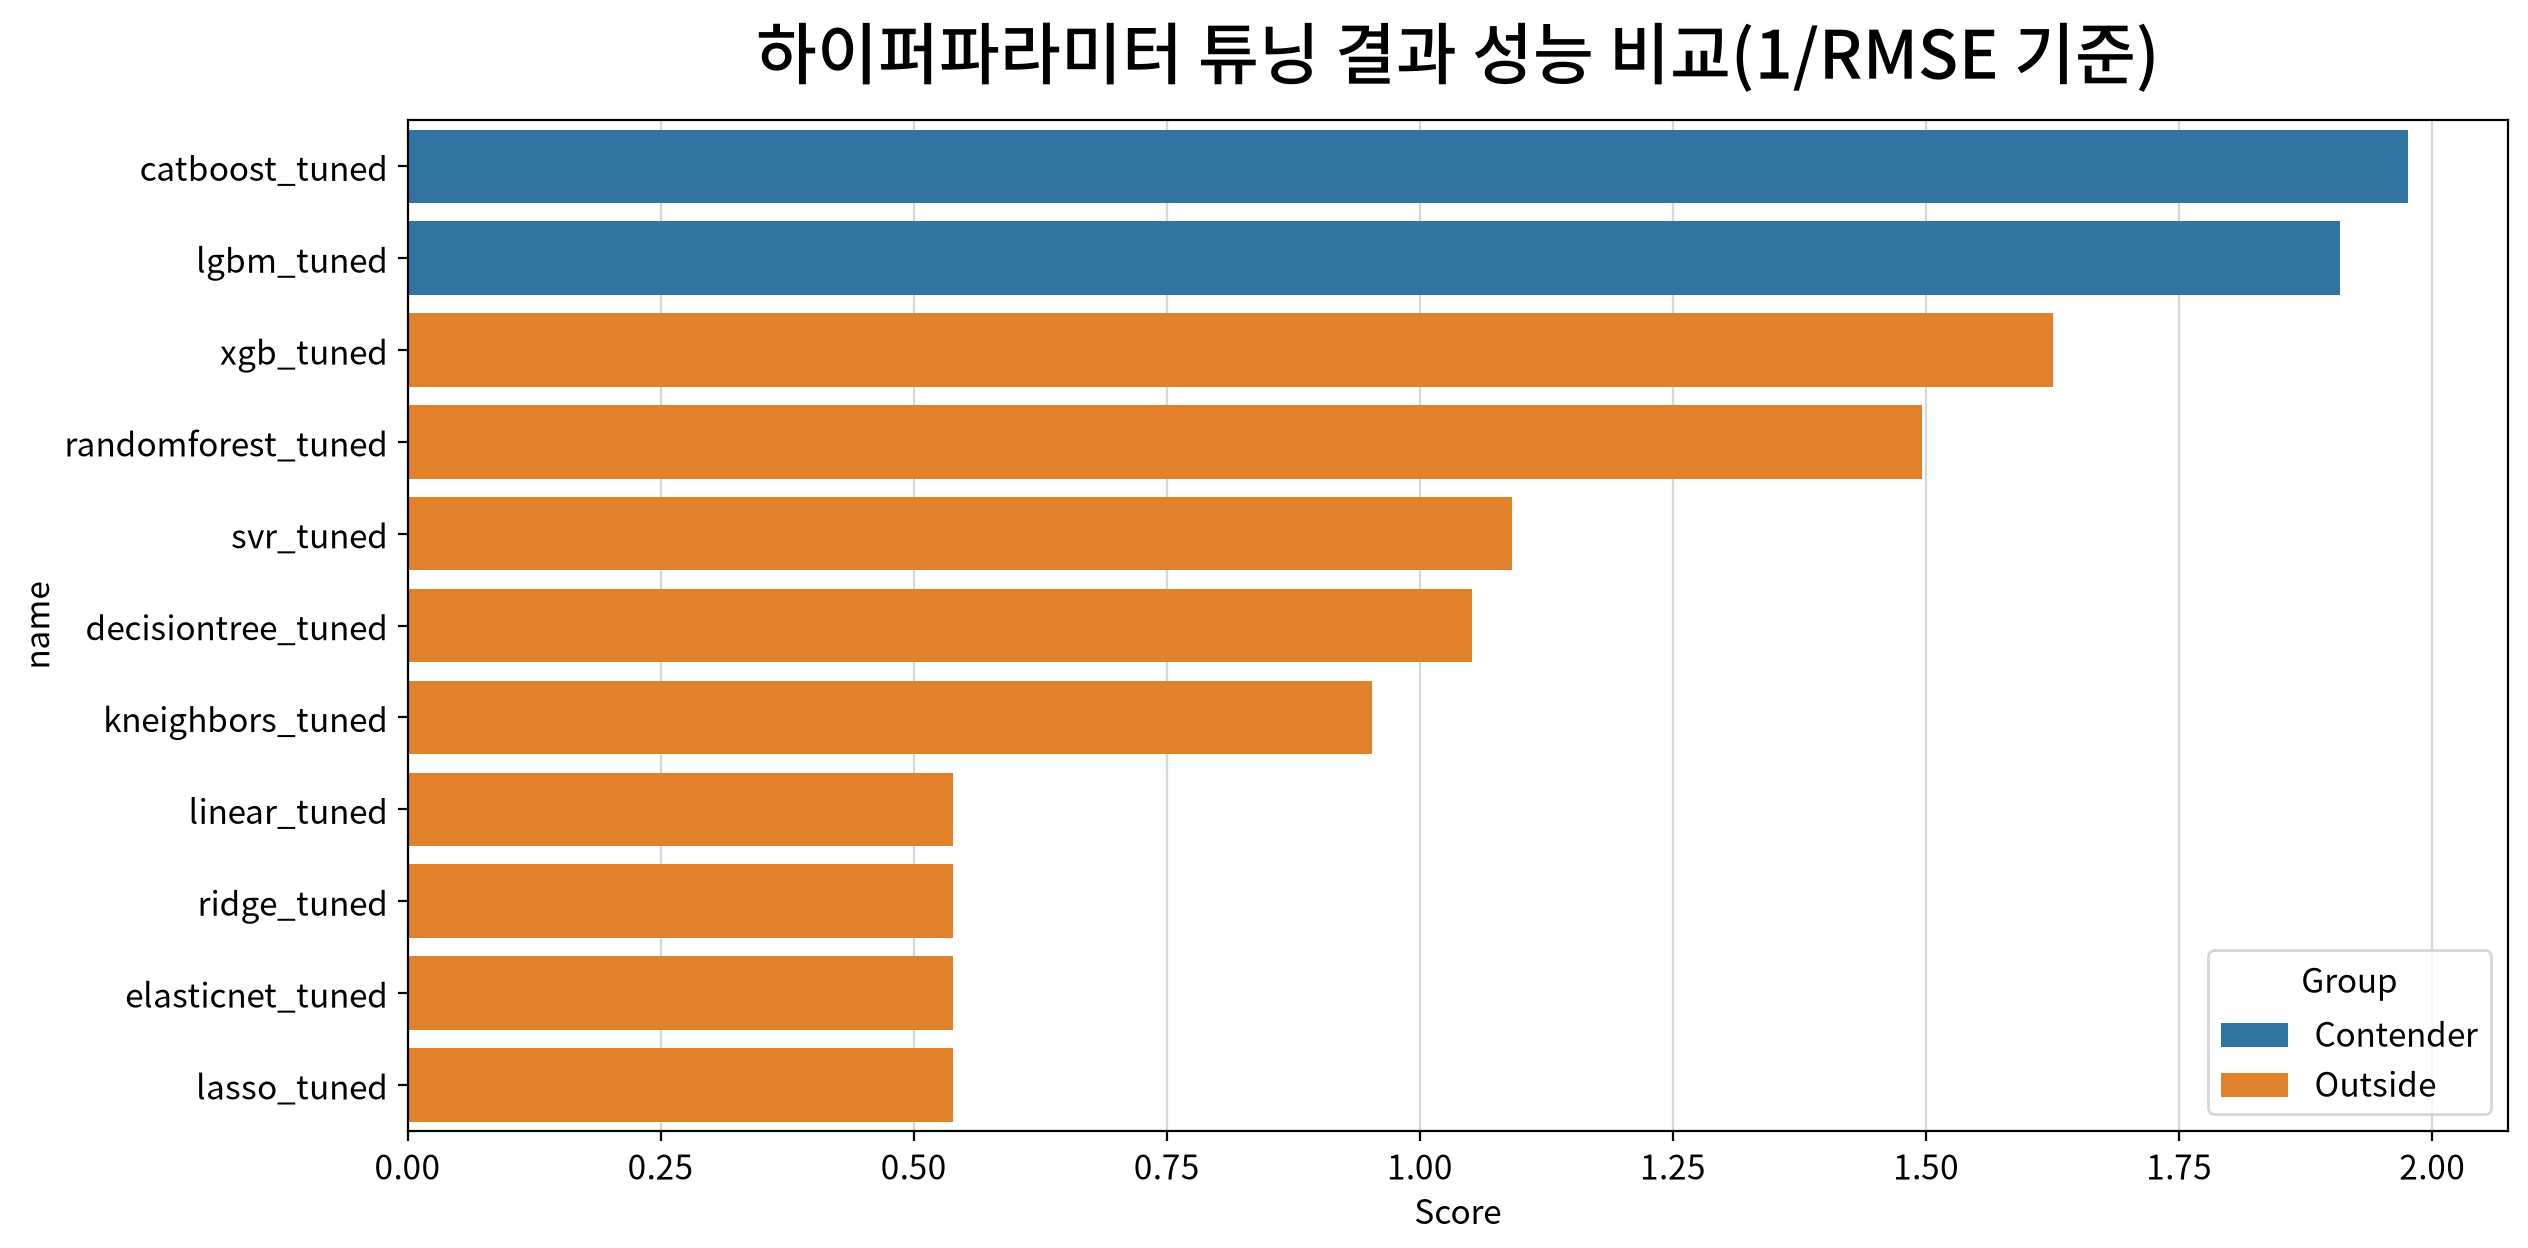


모델 11개 튜닝·저장 완료 → local\tuned


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
catboost_tuned,1,Contender,CatBoostRegressor,0.941,0.347,0.256,0.506,0.037,0.026,-0.003,0.000,1.976
lgbm_tuned,2,Contender,LGBMRegressor,0.937,0.354,0.274,0.524,0.039,0.027,-0.003,0.035,1.909
xgb_tuned,3,Outside,XGBRegressor,0.913,0.396,0.378,0.615,0.044,0.030,-0.004,0.215,1.626
randomforest_tuned,4,Outside,RandomForestRegressor,0.898,0.422,0.447,0.669,0.047,0.032,-0.005,0.321,1.496
svr_tuned,5,Outside,SVR,0.808,0.550,0.840,0.917,0.062,0.040,-0.005,0.811,1.091
decisiontree_tuned,6,Outside,DecisionTreeRegressor,0.793,0.558,0.904,0.951,0.065,0.041,-0.004,0.879,1.052
kneighbors_tuned,7,Outside,KNeighborsRegressor,0.748,0.668,1.102,1.050,0.069,0.048,-0.004,1.075,0.952
linear_tuned,8,Outside,LinearRegression,0.213,1.313,3.442,1.855,0.123,0.096,-0.020,2.666,0.539
ridge_tuned,9,Outside,Ridge,0.212,1.314,3.446,1.856,0.123,0.096,-0.020,2.668,0.539


CPU times: total: 8min 39s
Wall time: 48min 9s


In [9]:
%%time
my_ml.reg_tunes("local", models, x_train, y_train, x_test, y_test, practice=False)

### 튜닝 이후 CatBoost와 LightGBM을 최종 후보로 좁힌다

- CatBoost의 Test RMSE는 약 0.597에서 0.506으로, LightGBM은 약 0.652에서 0.524로 개선되어 두 모델이 상위 후보로 남았다.
- 교차검증 RMSE도 CatBoost가 약 0.510, LightGBM이 약 0.530으로 낮아, Test 순위뿐 아니라 CV 결과에서도 두 모델의 경쟁력이 확인된다.
- SVR은 튜닝으로 성능이 크게 개선됐지만, 상위 두 모델과의 차이는 남았다. 모델별로 기본 설정과 튜닝 후 성능을 구분해 평가할 필요가 있다.
- 현재 수치는 최종 후보를 좁히는 근거이며, 최종 선택 전에는 훈련 성능과의 격차 및 학습곡선을 함께 검토한다.

# 5부. 모델을 검증하고 해석하는 단계
### 미션 10. "점수가 배운 것인지 외운 것인지 가른다"

In [10]:
# 독립변수 분리
feature = df.drop(columns=["매출금액"])

# 종속변수 분리
target = df["매출금액"]

# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4992, 15), (1248, 15), (4992,), (1248,))

In [11]:
# 튜닝이 완료된 모델이 저장되어 있는 폴더 위치 지정
project_name = "local"
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

In [12]:
models = {
    "catboost": my_ml.load_model(f"{tuned_dir}/catboost_tuned.pkl"),
    "lgbm": my_ml.load_model(f"{tuned_dir}/lgbm_tuned.pkl")
}

#### ▶︎ catboost

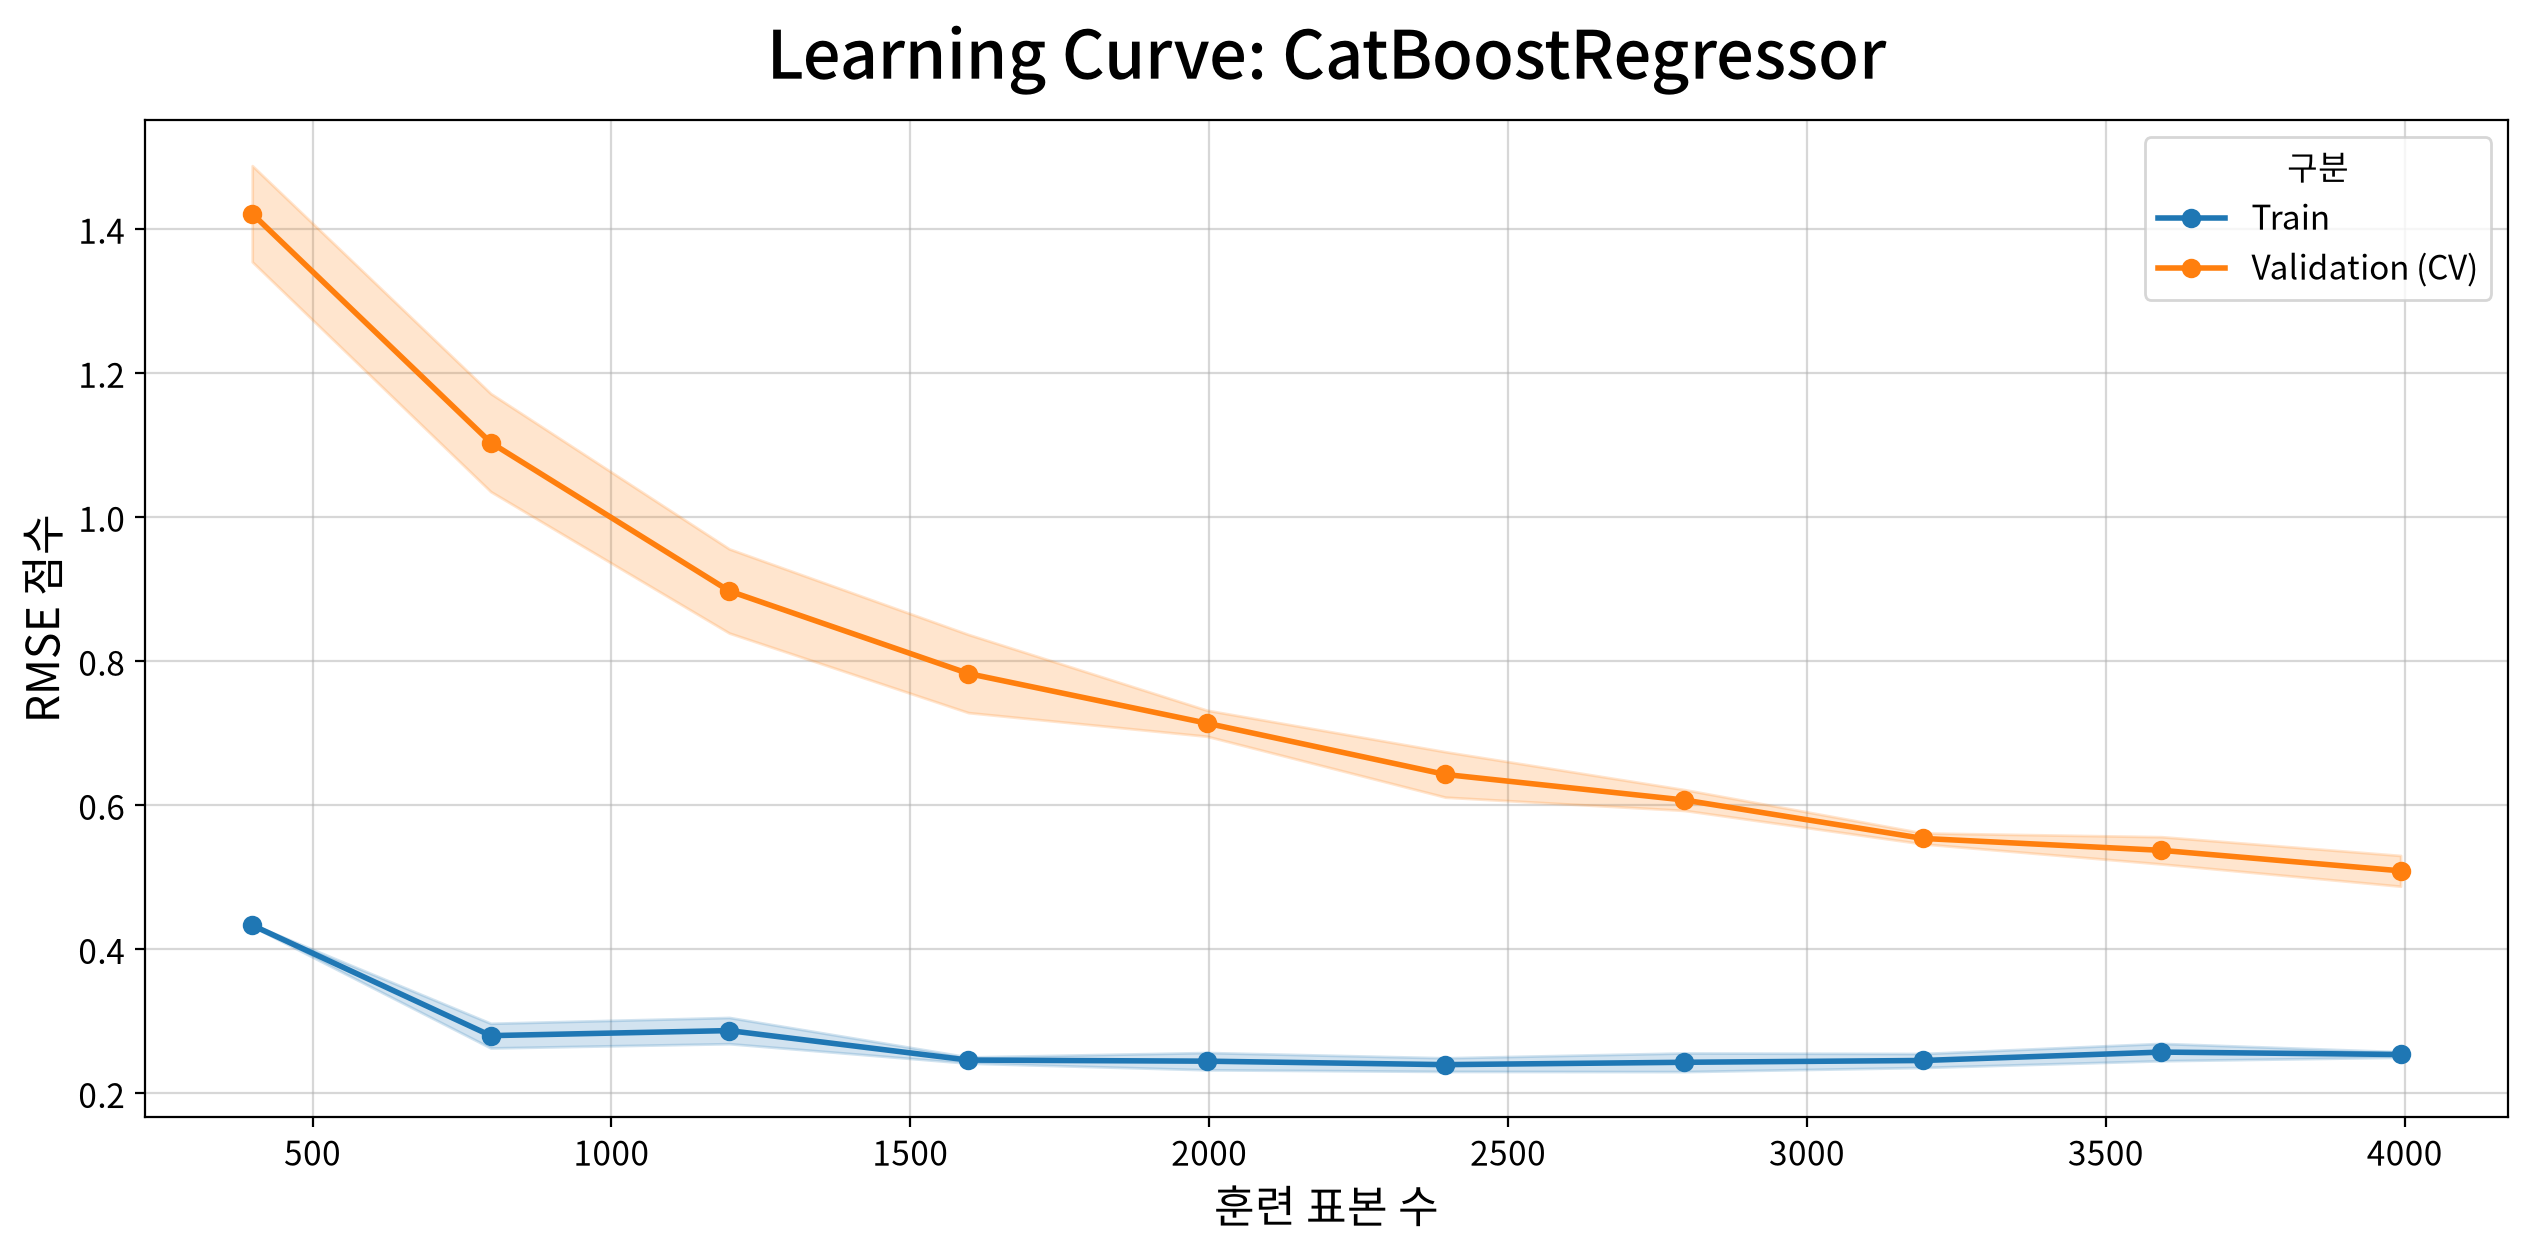

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.278,0.510,0.023,0.506,0.232,45.470,과대적합
MAE,0.201,0.348,0.009,0.347,0.147,42.120,과대적합
R2,0.981,0.937,0.005,0.941,0.045,4.450,일반화



◆ Fit Diagnosis: CatBoostRegressor  (threshold=20%, 기준=Train↔CV 5-Fold)
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - RMSE    Train=     0.2779  CV=     0.5097 (±0.0229)  Test=     0.5061  Gap%=   45.47%  [과대적합] [주의]
  - MAE     Train=     0.2014  CV=     0.3479 (±0.0089)  Test=     0.3472  Gap%=   42.12%  [과대적합] [주의]
  - R2      Train=     0.9812  CV=     0.9367 (±0.0045)  Test=     0.9414  Gap%=    4.45%  [일반화] [정상]

  ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) - 훈련↔CV 격차가 큼
      · train R2=0.9812 (과소적합 기준 < 0.05) · CV R2=0.9367



#### ▶︎ lgbm

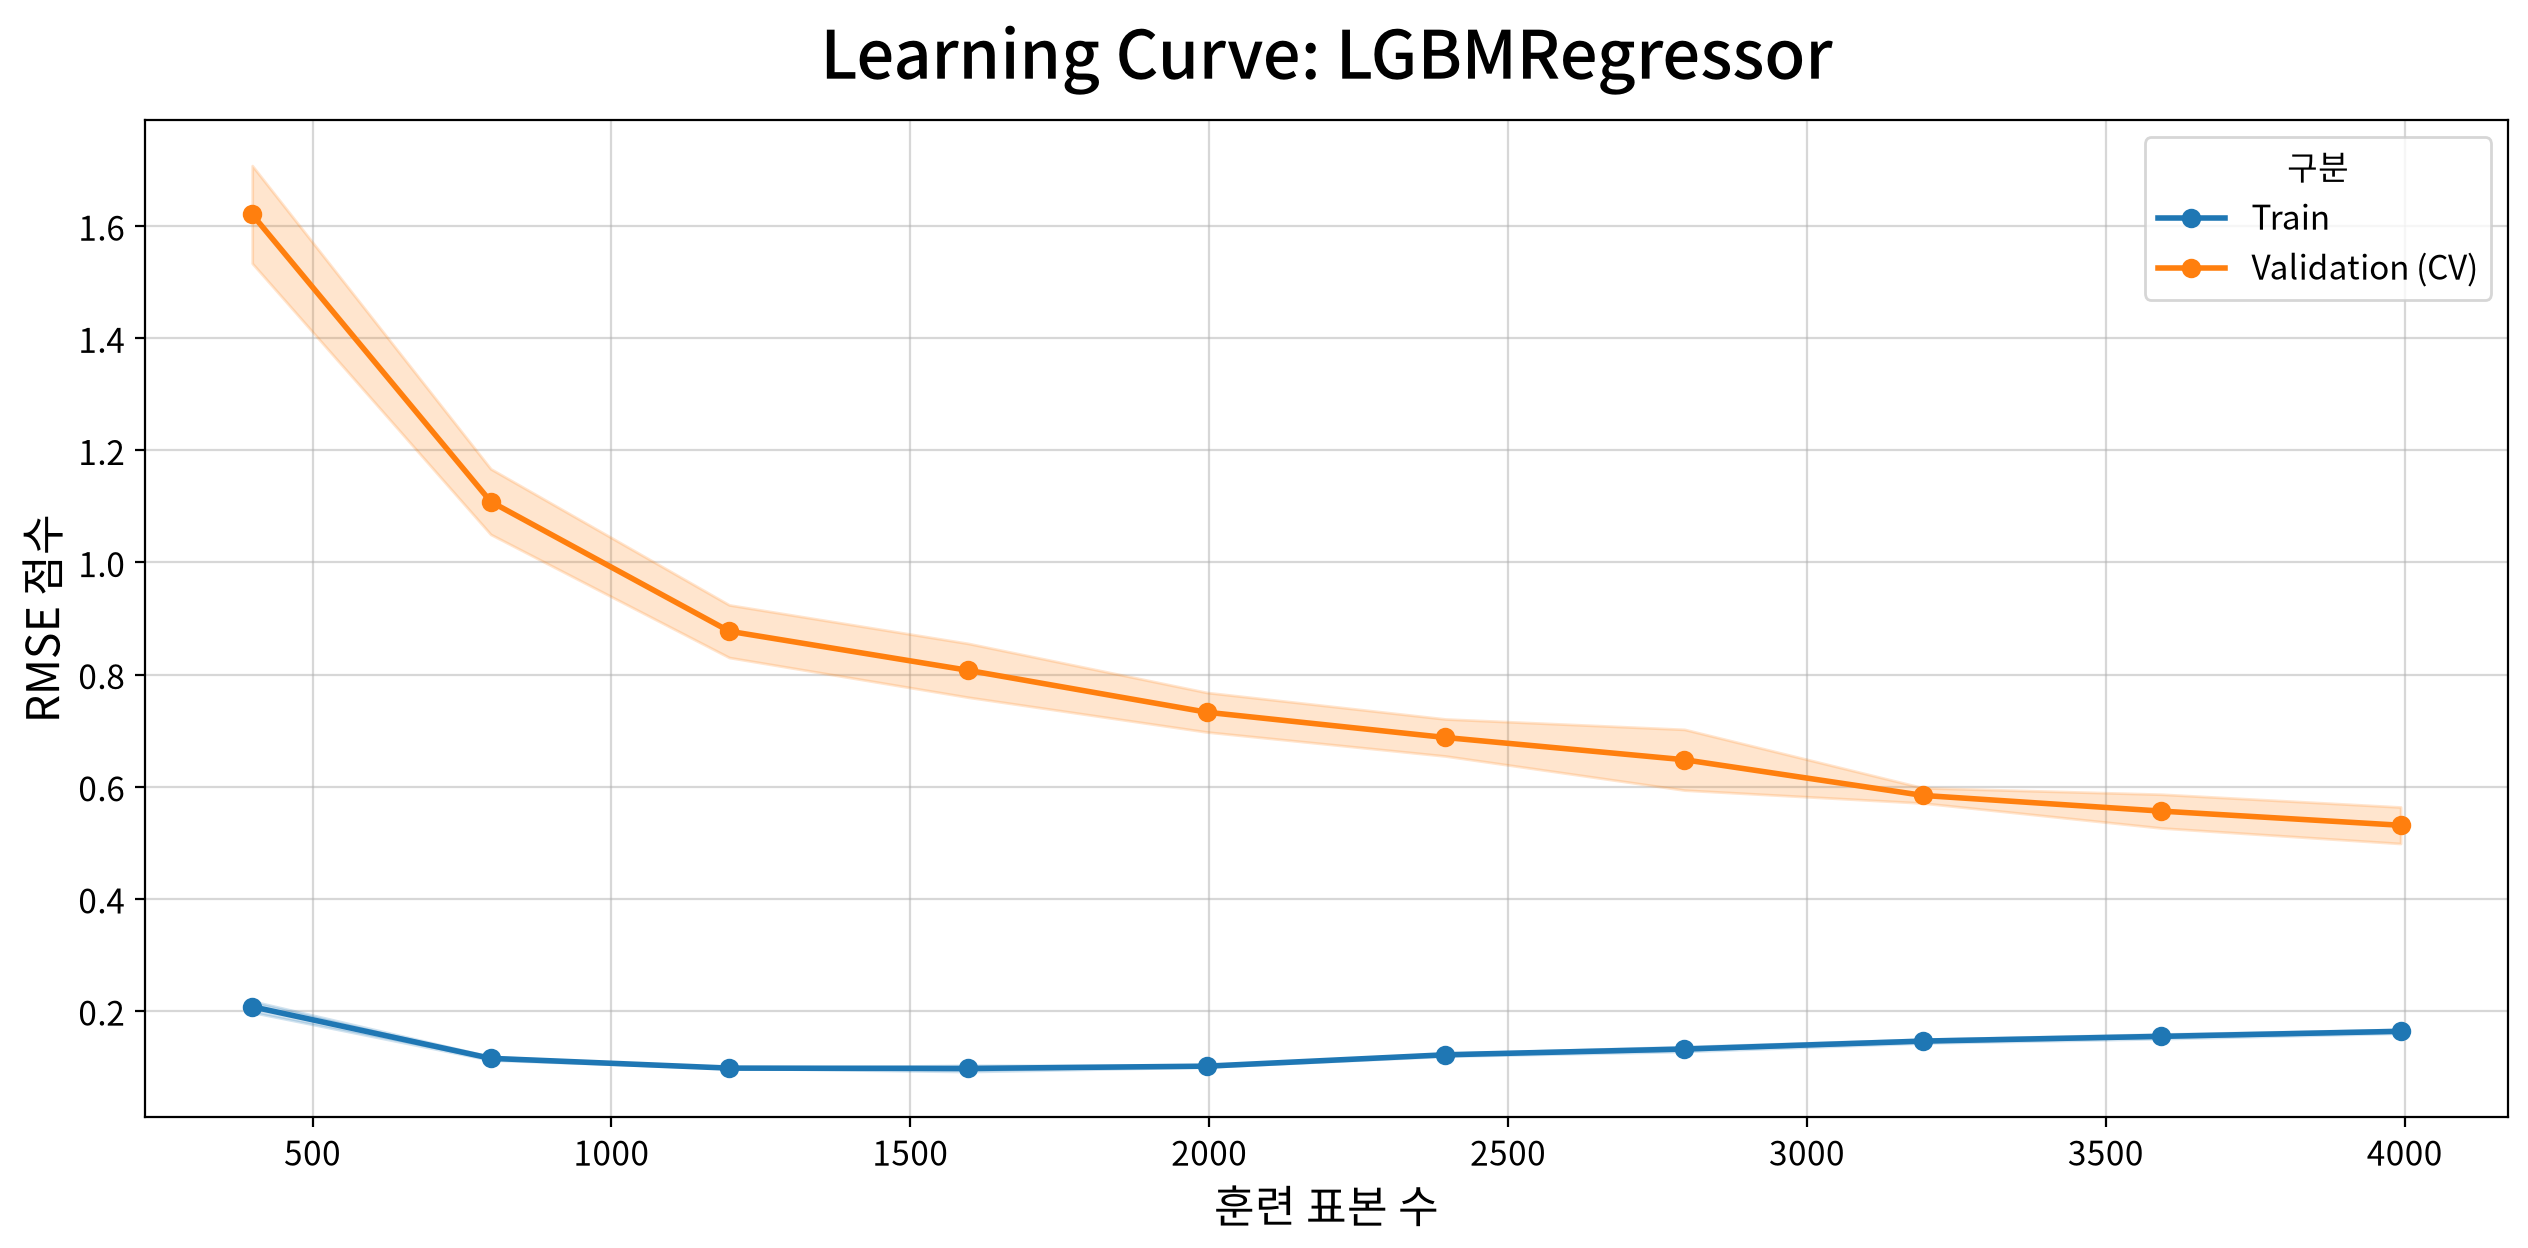

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.183,0.530,0.029,0.524,0.348,65.550,과대적합
MAE,0.129,0.365,0.020,0.354,0.236,64.590,과대적합
R2,0.992,0.931,0.008,0.937,0.061,6.060,일반화



◆ Fit Diagnosis: LGBMRegressor  (threshold=20%, 기준=Train↔CV 5-Fold)
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - RMSE    Train=     0.1827  CV=     0.5302 (±0.0287)  Test=     0.5238  Gap%=   65.55%  [과대적합] [주의]
  - MAE     Train=     0.1291  CV=     0.3647 (±0.0203)  Test=     0.3544  Gap%=   64.59%  [과대적합] [주의]
  - R2      Train=     0.9919  CV=     0.9313 (±0.0079)  Test=     0.9372  Gap%=    6.06%  [일반화] [정상]

  ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) - 훈련↔CV 격차가 큼
      · train R2=0.9919 (과소적합 기준 < 0.05) · CV R2=0.9313

CPU times: total: 5.45 s
Wall time: 23min 10s


In [13]:
%%time

for model_name, model in models.items():
    display(Markdown(f"#### ▶︎ {model_name}"))
    my_diag.overfit(model, x_train, y_train, x_test, y_test)

### 높은 시험 성능과 훈련 과적합 신호가 함께 나타난다

- 두 후보 모두 CV와 Test 오차는 비슷하지만, Train 오차는 상당히 낮다. 시험 성능이 높다는 사실만으로 과적합이 없다고 판단할 수 없다.
- RMSE 기준 Train–CV 격차율은 CatBoost 약 45.5%, LightGBM 약 65.6%다. CatBoost가 상대적으로 작지만 두 모델 모두 훈련 자료에 더 잘 맞는 경향이 남아 있다.
- 학습곡선에서도 훈련 표본이 증가할수록 CV 오차가 줄어들지만, 마지막 구간까지 Train과 CV 사이의 차이가 유지된다.
- 출력의 20% 판정 기준은 경험적 기준이다. 자동 판정 하나보다 오차 수준·격차·학습곡선을 종합해 해석한다.

### CatBoost를 우선 검토할 최종 후보로 유지

- CatBoost는 LightGBM보다 CV 오차가 낮고, CV 점수의 변동과 Train–CV 격차도 상대적으로 작다. 현재 확인된 기준에서는 우선 검토할 근거가 있다.
- 다만 두 모델 모두 과적합 신호가 남아 있고, 행정동·시간을 분리한 평가가 없어 새로운 지역이나 미래 기간에 대한 일반화까지 확인된 것은 아니다.
- 다음 단계에서는 CatBoost의 변수 중요도를 확인하고, 중요도가 낮은 변수를 제외한 재학습 모델과 비교해 최종 사용 모델을 결정한다.

### 변수 중요도 해석을 위한 확인 지점

- ※ 변수 중요도 분석 완료 후 이 위치에 인사이트 작성 필요
- 상위 변수와 정보가 겹치는 변수들의 중요도 분포를 확인하되, 중요도를 매출 증가 효과나 관계의 방향으로 해석하지 않는다.
- 군집 중요도가 낮게 나타나더라도 예측에 추가되는 정보가 적다는 판단과 지역 유형화의 활용 가치는 구분한다.

### 지역 유형별로 다른 정책 검토 질문 설정

- 인구 대비 유동인구가 높지만 평균 지역화폐 매출은 낮은 군집 1은, 유동 특성과 실제 사용처·이용자 구성의 연결을 추가로 살펴볼 대상으로 검토할 수 있다. 현재 결과만으로 구매 전환이 낮다고 확정하지 않는다.
- 인구 대비 가맹점 수가 높은 군집 3은 평균매출과 중앙값의 차이가 크다. 군집 전체를 활성 지역으로 분류하기보다 내부의 낮은 매출 지역을 구분해 살펴볼 필요가 있다.
- 평균매출이 비슷한 군집 2와 4도 인구 규모와 업종 구성이 다르다. 매출 순위만으로 같은 정책 대상으로 묶기보다 지역 특성에 따른 접근을 검토할 수 있다.
- 이러한 구분은 정책 대상과 점검 항목을 설정하는 데 활용할 수 있으나, 특정 지원책의 효과나 시행 우선순위를 검증한 결과는 아니다.

In [12]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = pd.read_excel("local_features_log_labeled.xlsx")
df = my_qtcheck.set_type(origin, as_category=["기준월", "년도", "spatial_cluster"])

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   총인구수              6240 non-null   float64 
 1   만명당_가맹점수          6240 non-null   float64 
 2   spatial_cluster   6240 non-null   category
 3   기준월               6240 non-null   category
 4   년도                6240 non-null   category
 5   만명당_가맹점수_소매       6240 non-null   float64 
 6   만명당_가맹점수_음식       6240 non-null   float64 
 7   만명당_가맹점수_부동산      6240 non-null   float64 
 8   만명당_가맹점수_과학·기술    6240 non-null   float64 
 9   만명당_가맹점수_시설관리·임대  6240 non-null   float64 
 10  만명당_가맹점수_보건의료     6240 non-null   float64 
 11  만명당_가맹점수_예술·스포츠   6240 non-null   float64 
 12  만명당_가맹점수_수리·개인    6240 non-null   float64 
 13  만명당_가맹점수_기타       6240 non-null   float64 
 14  가맹점당_월유동인구        6240 non-null   float64 
 15  매출금액              6240 non-null   float64 
dtypes: category(3), float64(13)
memory 

In [13]:
# 독립변수 분리
feature = df.drop(columns=["매출금액"])

# 종속변수 분리
target = df["매출금액"]

# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4992, 15), (1248, 15), (4992,), (1248,))

### 저장폴더 구성

In [14]:
# 튜닝 완료된 모델이 저장되어있는 폴더
project_name = "local"
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

# feature importance 기반 재학습된 모델이 저장될 폴더
work_dir = f"{project_name}/importance"

if not os.path.exists(work_dir):
    os.makedirs(work_dir)

### 임계값 정하기

In [15]:
cum_ratio = 0.95

if not 0.0 < cum_ratio <= 1.0:    # (0, 1] 범위를 벗어난 경우
        raise ValueError(f"cum_ratio 는 (0.0, 1.0] 범위여야 합니다: {cum_ratio}")

### 6. 하이퍼파라미터 튜닝 후 최고 성능 모델 로드 및 성능 확인

In [16]:
estimator = my_ml.load_model(f"{tuned_dir}/catboost_tuned.pkl")
my_ml.reg_score(estimator, x_test, y_test)

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
CatBoostRegressor,0.941,0.347,0.256,0.506,0.037,0.026,-0.003


### 7. catboost 모델에 대한 Feature Importance

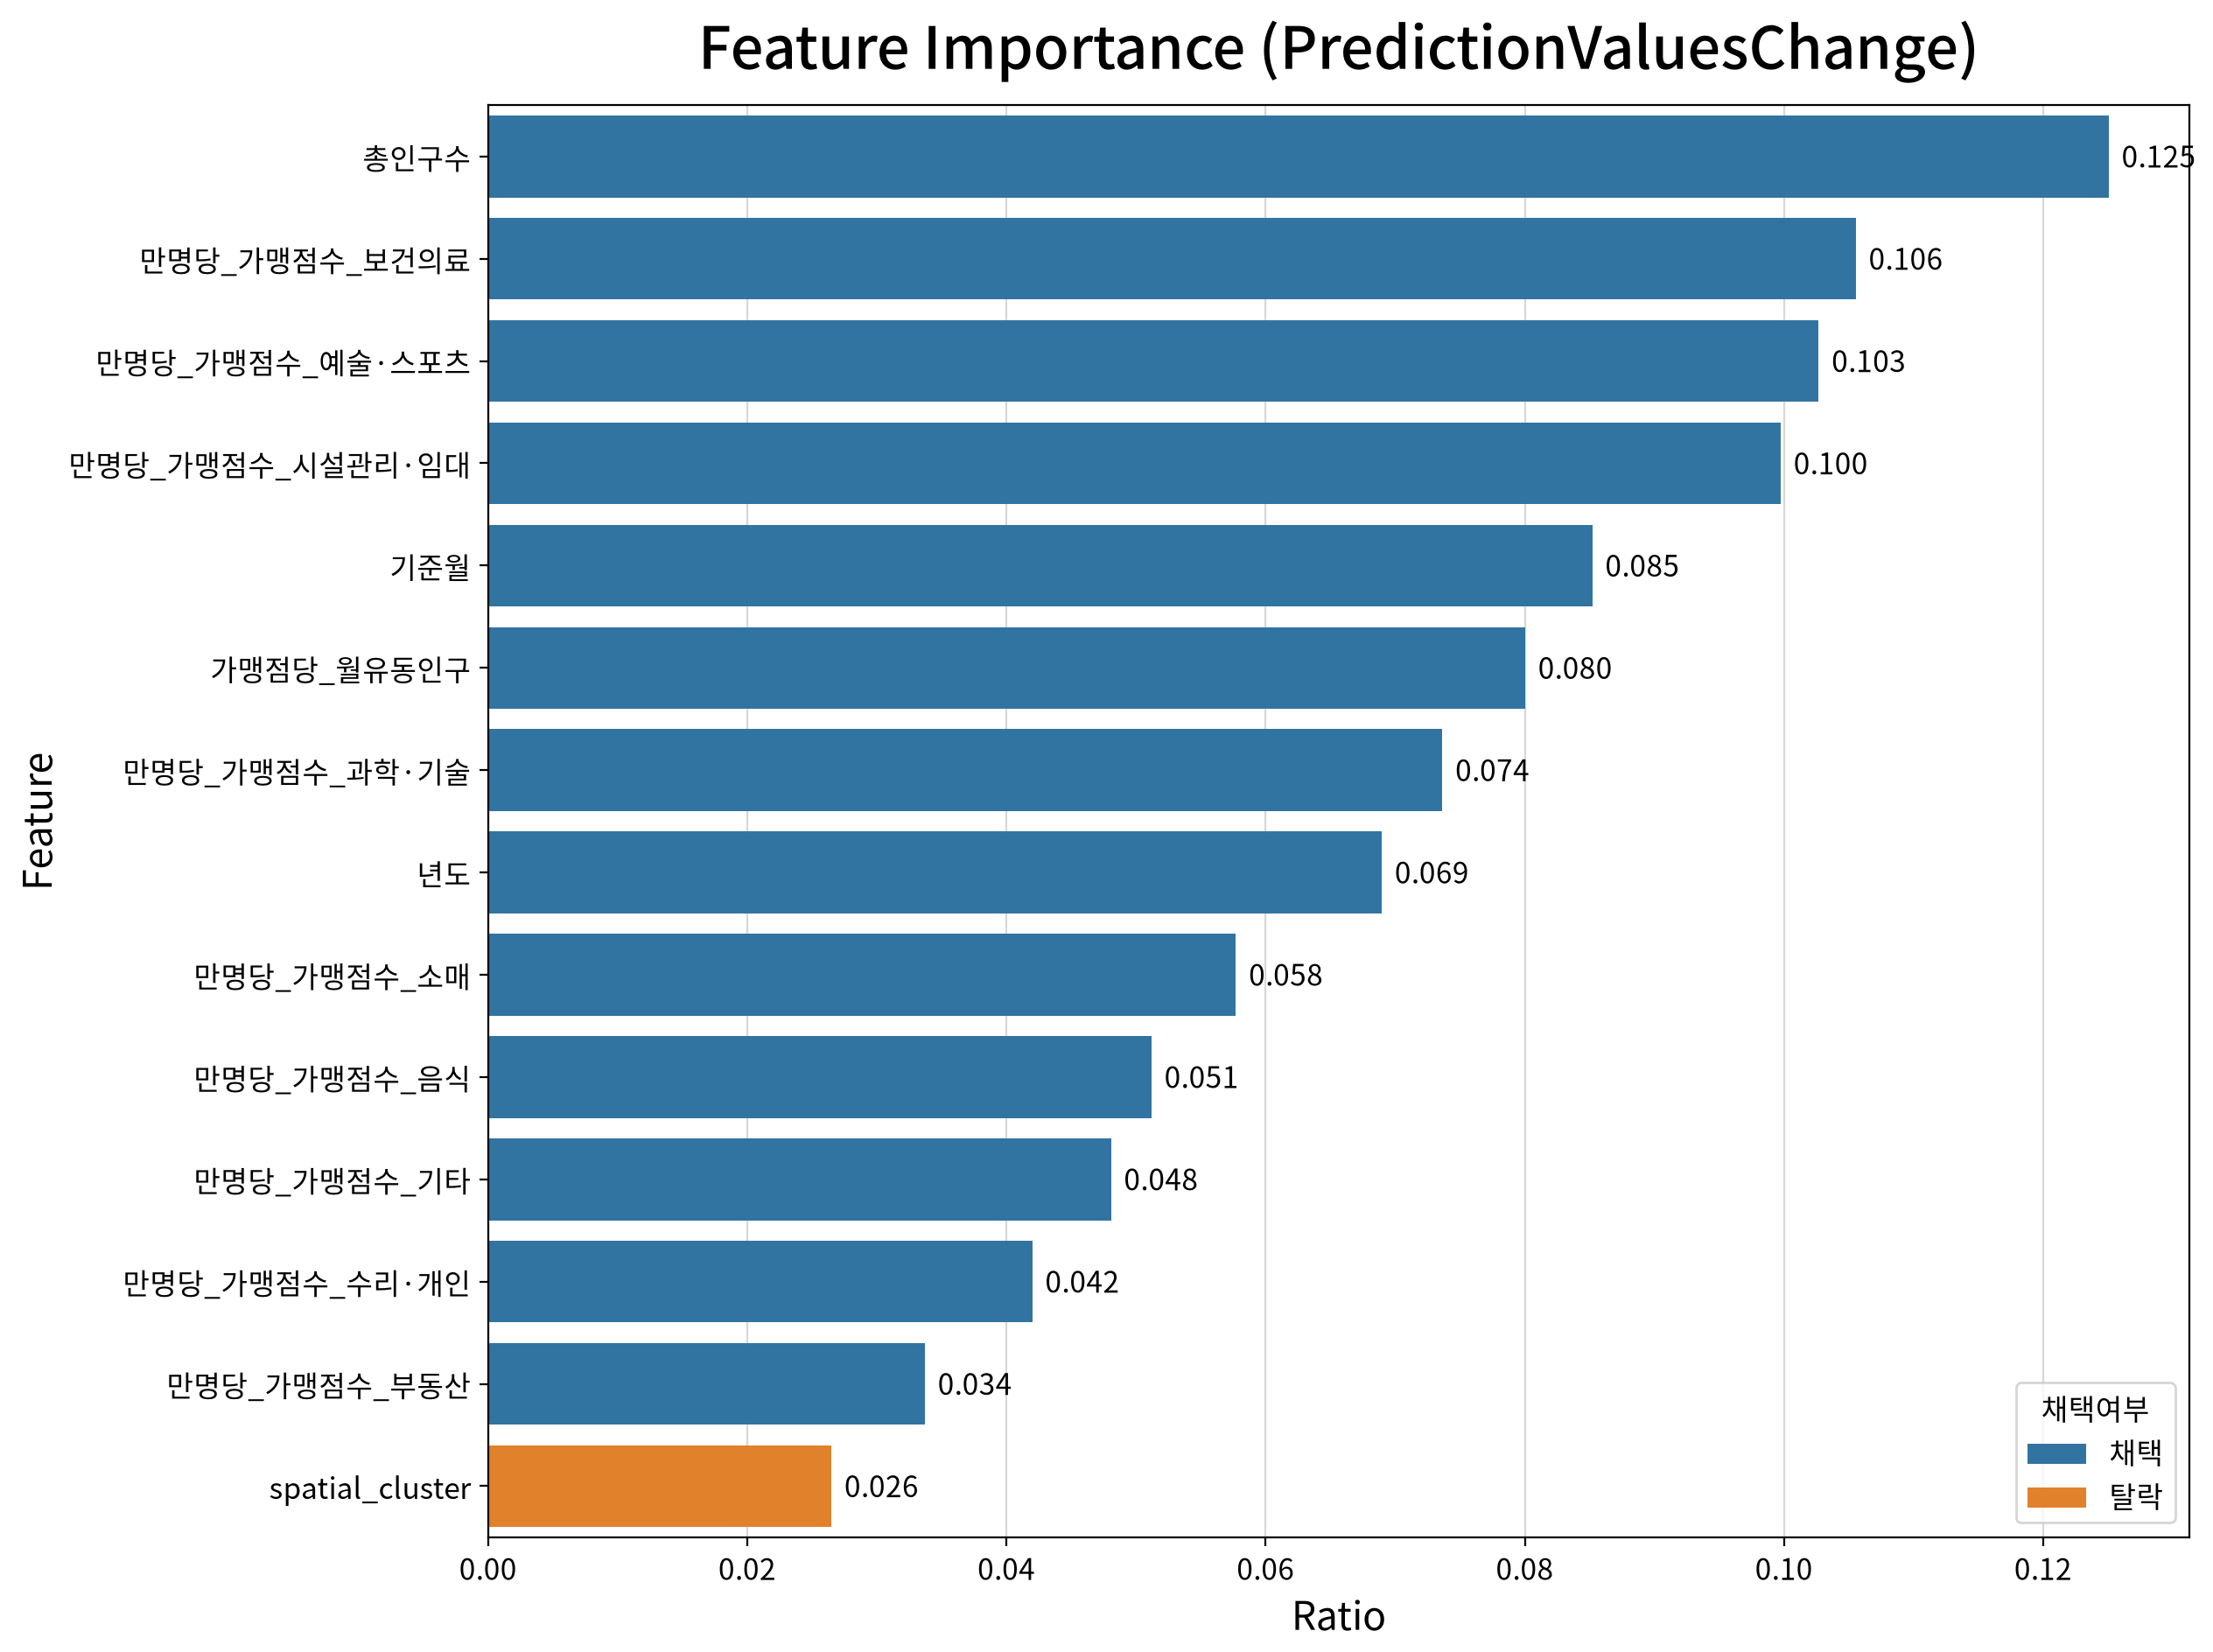

,Importance,Ratio,CumRatio,채택여부
Feature,,,,
총인구수,12.505,0.125,0.125,채택
만명당_가맹점수_보건의료,10.554,0.106,0.231,채택
만명당_가맹점수_예술·스포츠,10.268,0.103,0.333,채택
만명당_가맹점수_시설관리·임대,9.975,0.100,0.433,채택
기준월,8.521,0.085,0.518,채택
가맹점당_월유동인구,8.003,0.080,0.598,채택
만명당_가맹점수_과학·기술,7.364,0.074,0.672,채택
년도,6.896,0.069,0.741,채택
만명당_가맹점수_소매,5.771,0.058,0.799,채택


In [17]:
fi = my_diag.feature_importance(estimator, cum_ratio=0.95)
fi

- 변수 중요도에서는 총인구수가 가장 높고, 보건의료·예술·스포츠·시설관리·임대의 인구 대비 가맹점 수가 뒤를 이었다. 모델은 여러 인구·업종 지표에 예측 정보를 분산해 사용한다.
- `spatial_cluster`의 중요도 비중은 약 2.65%로 출력된 변수 중 가장 낮아, 누적 중요도 95% 기준의 선택에서 제외됐다.
- 이 결과는 현재 모델에서 군집의 상대적 예측 중요도가 낮다는 뜻이다. 군집이 매출을 설명하는 핵심 변수라고 해석하지 않는다.
- 앞선 군집별 인구·업종 특성 비교는 지역 유형에 대한 분석이고, 여기의 중요도는 모델의 예측에 대한 평가다. 두 결과의 의미는 구분한다.

### 채택된 변수 추출

In [18]:
feature_names = fi[fi['채택여부'] == '채택'].index.tolist()
feature_names

['총인구수',
 '만명당_가맹점수_보건의료',
 '만명당_가맹점수_예술·스포츠',
 '만명당_가맹점수_시설관리·임대',
 '기준월',
 '가맹점당_월유동인구',
 '만명당_가맹점수_과학·기술',
 '년도',
 '만명당_가맹점수_소매',
 '만명당_가맹점수_음식',
 '만명당_가맹점수_기타',
 '만명당_가맹점수_수리·개인',
 '만명당_가맹점수_부동산']

### 채택된 변수 필터링

In [19]:
x_train_imp = x_train[feature_names]
x_test_imp = x_test[feature_names]

print("원본 훈련 데이터셋 변수 개수:", x_train.shape[1])
print("원본 검증 데이터셋 변수 개수:", x_test.shape[1])
print("채택된 변수만 남긴 훈련 데이터셋 변수 개수:", x_train_imp.shape[1])
print("채택된 변수만 남긴 검증 데이터셋 변수 개수:", x_test_imp.shape[1])

원본 훈련 데이터셋 변수 개수: 15
원본 검증 데이터셋 변수 개수: 15
채택된 변수만 남긴 훈련 데이터셋 변수 개수: 13
채택된 변수만 남긴 검증 데이터셋 변수 개수: 13


## 채택된 변수로 재학습
### 베이스라인 모델 재학습

In [20]:
from catboost import CatBoostRegressor

# CatBoost 기본모델
model = CatBoostRegressor(random_state=RANDOM_STATE, verbose=0)

model_name = model.__class__.__name__.lower().removesuffix('regressor')

model_imp = my_ml.fit_pipeline(
    model=model, x_train=x_train_imp, y_train=y_train,
    vif=True, scale=False, encode=False,
    name=model_name, save_path=f"{work_dir}/{model_name}_imp.pkl",
    verbose=False,
    model__cat_features=my_qtcheck.get_categorical_column_names(x_train_imp))

model_imp

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('vif_selector',
                                                                   VIFSelector())]),
                                                  ['총인구수', '만명당_가맹점수_보건의료',
                                                   '만명당_가맹점수_예술·스포츠',
                                                   '만명당_가맹점수_시설관리·임대',
                                                   '가맹점당_월유동인구',
                                                   '만명당_가맹점수_과학·기술',
                                                   '만명당_가맹점수_소매', '만명당_가맹점수_음식',
                                                   '만명당_가맹점수_기타',
                                                   '만명당_가맹점수_수리·개인',
                                                   '만명당_가맹점수_부동산']),
                                   

### 하이퍼파라미터 튜닝

In [22]:
%%time

models = {"catboost_imp": model_imp}

my_ml.reg_tunes(
    project_name,
    models,
    x_train=x_train_imp,
    y_train=y_train,
    x_test=x_test_imp,
    y_test=y_test,
    practice=True,
    plot=False,
    workdir="importance"
)

작업 폴더: local\importance
탐색 범위: 실습용(축소)
탐색 완료 [ 1/ 1] : catboost_imp (531.0초, CV RMSE=0.5232)
    최적 조합: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.1}

모델 1개 튜닝·저장 완료 → local\importance


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
catboost_imp_tuned,1,Contender,CatBoostRegressor,0.941,0.353,0.257,0.507,0.037,0.027,-0.003,0.000,1.974


CPU times: total: 3min 13s
Wall time: 8min 50s


### 과적합 진단

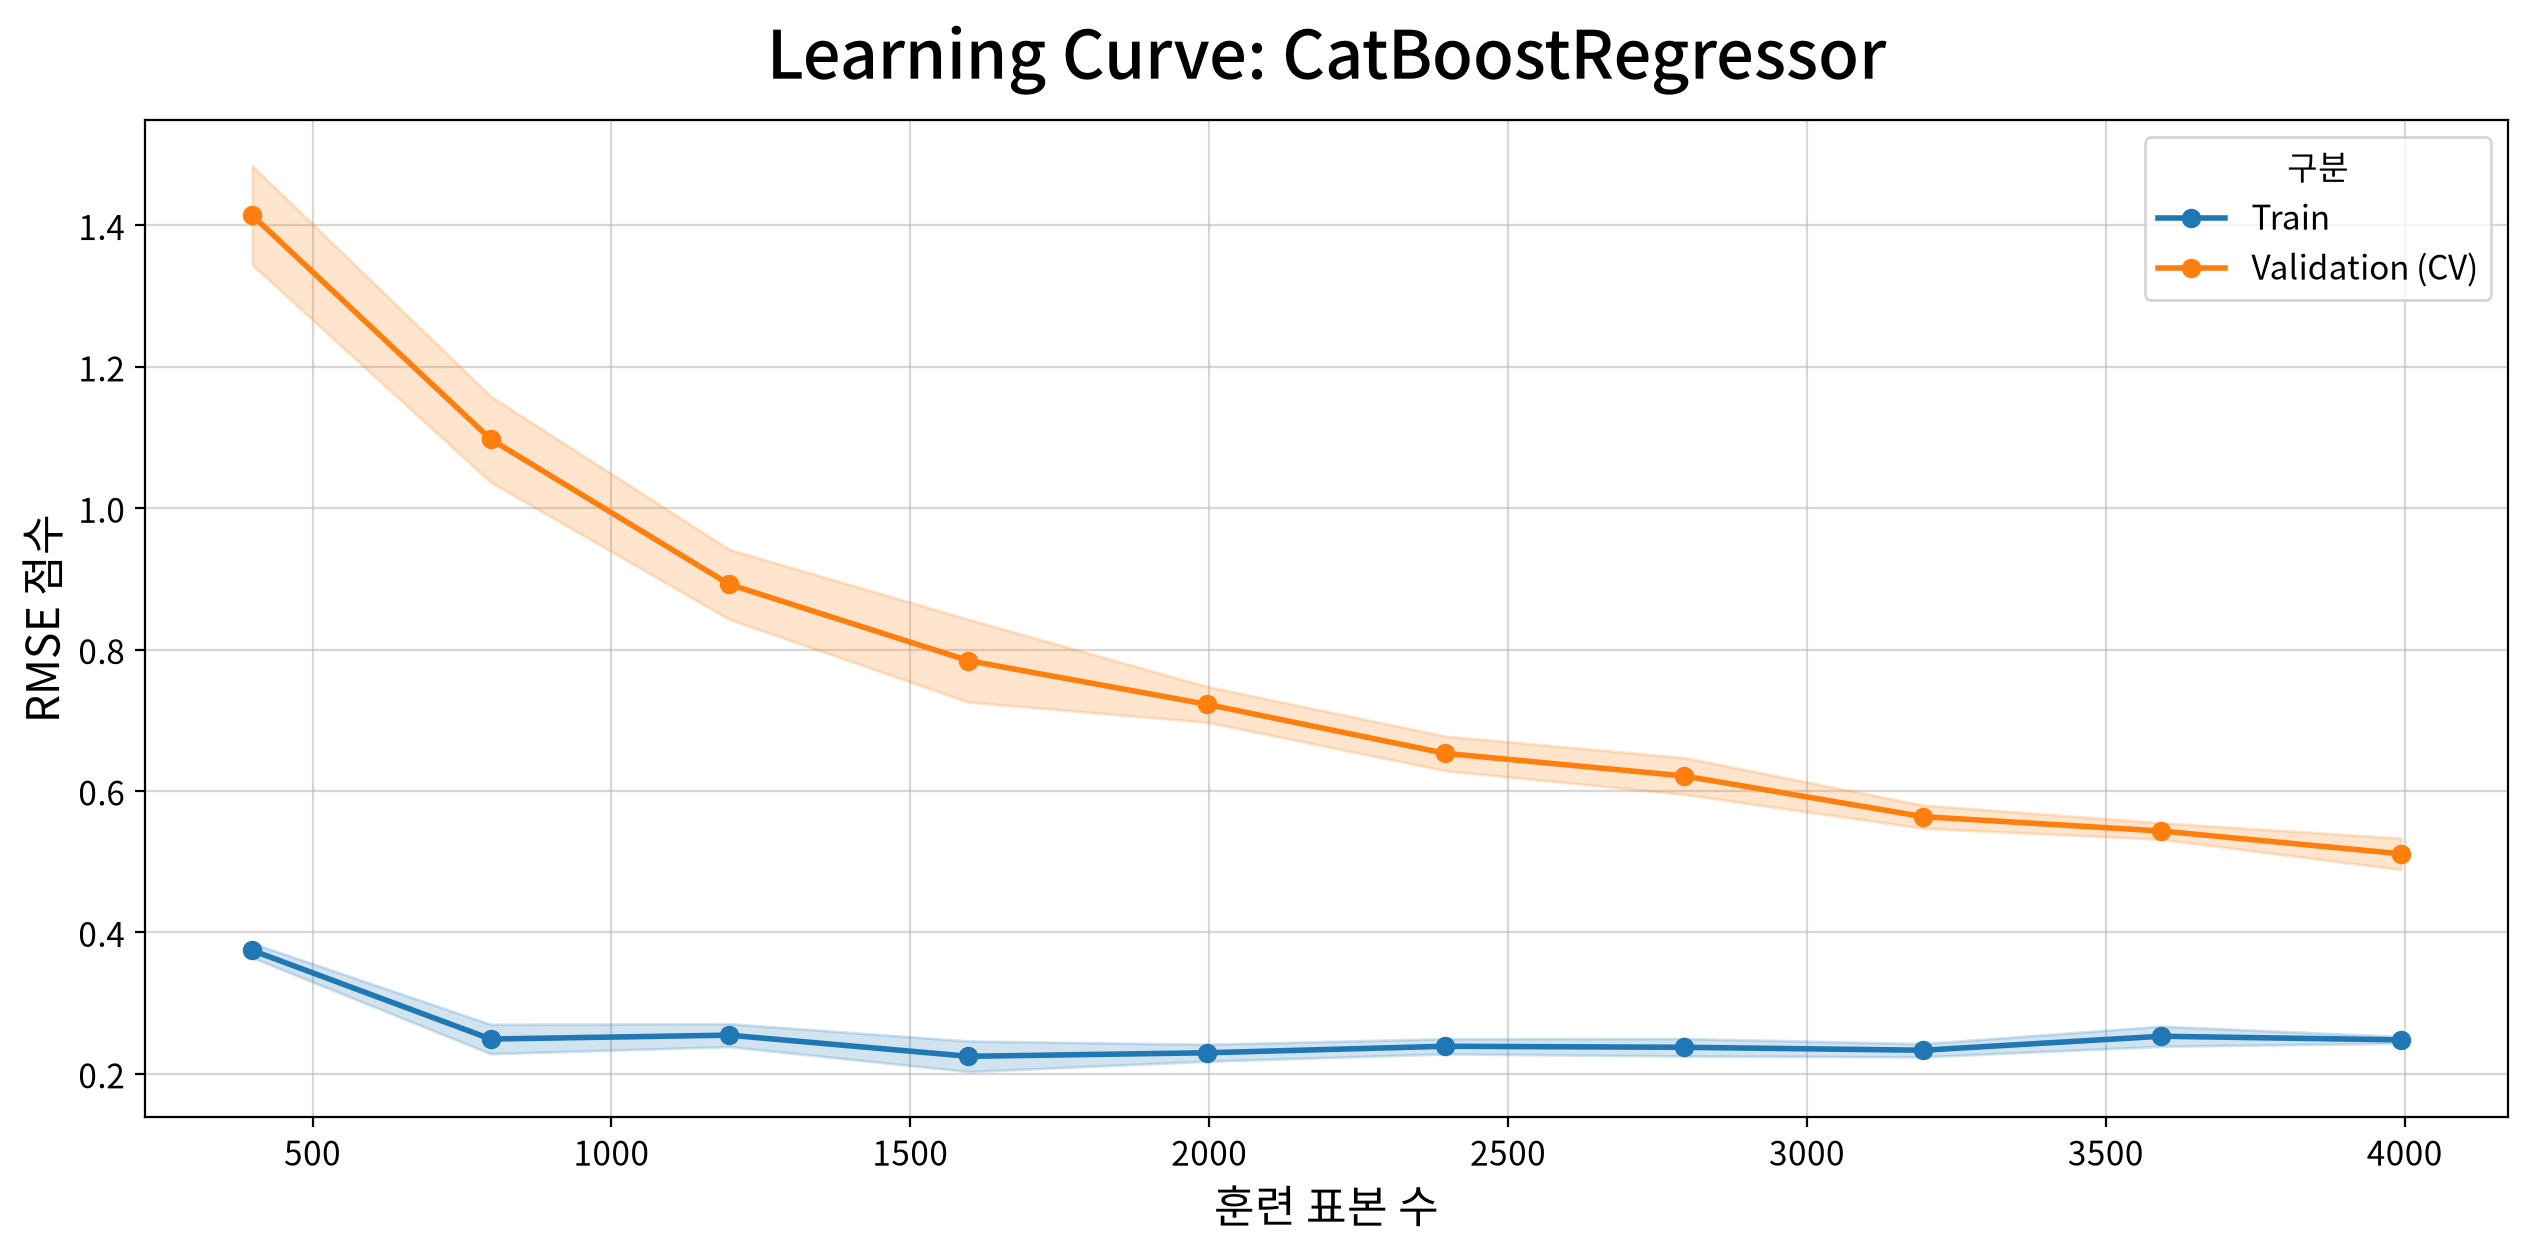

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.271,0.523,0.019,0.507,0.253,48.290,과대적합
MAE,0.197,0.353,0.008,0.353,0.156,44.210,과대적합
R2,0.982,0.933,0.004,0.941,0.049,4.890,일반화



◆ Fit Diagnosis: CatBoostRegressor  (threshold=20%, 기준=Train↔CV 5-Fold)
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - RMSE    Train=     0.2706  CV=     0.5232 (±0.0193)  Test=     0.5066  Gap%=   48.29%  [과대적합] [주의]
  - MAE     Train=     0.1970  CV=     0.3530 (±0.0080)  Test=     0.3530  Gap%=   44.21%  [과대적합] [주의]
  - R2      Train=     0.9822  CV=     0.9333 (±0.0038)  Test=     0.9413  Gap%=    4.89%  [일반화] [정상]

  ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) - 훈련↔CV 격차가 큼
      · train R2=0.9822 (과소적합 기준 < 0.05) · CV R2=0.9333

CPU times: total: 1.48 s
Wall time: 9min 57s


In [23]:
%%time

# 튜닝된 모델 로드
tune_model = my_ml.load_model(f"{work_dir}/catboost_imp_tuned.pkl")

# 튜닝된 모델의 과적합 여부를 확인
my_diag.overfit(tune_model, x_train=x_train_imp, y_train=y_train,
                x_test=x_test_imp, y_test=y_test,
                fit_params={"model__cat_features":
                    my_qtcheck.get_categorical_column_names(x_train_imp)})

### 변수 축소 이후 성능 개선은 확인되지 않았다

- 변수 선택 후 Test RMSE는 0.5061에서 0.5066으로 약 0.0005 높아졌다. 차이는 작지만, 이번 출력에서는 오차 감소가 아니라 소폭 증가다.
- CV RMSE도 0.5097에서 0.5232로 높아졌고, Train–CV 격차율은 45.47%에서 48.29%로 커졌다. 변수 축소로 예측 성능이나 과적합이 개선됐다고 볼 근거는 확인되지 않았다.
- 두 모델은 같은 데이터와 분할 설정으로 비교했지만, 선택 후 모델에는 축소된 튜닝 범위를 사용했고 최적 설정도 달라졌다.
- 따라서 이 차이는 두 학습 결과의 비교이며, 군집 제거 하나의 효과로 해석하지 않는다.

### 변수 선택 전 CatBoost를 최종 사용 모델로 선정

- 이번 프로젝트의 최종 사용 모델은 `spatial_cluster`를 포함한 변수 선택 전 CatBoost로 결정한다. 현재 비교에서 Test·CV 오차와 Train–CV 격차가 모두 선택 후 모델보다 낮았다.
- Test RMSE 차이는 약 0.0005로 작으며, 반복 비교나 차이에 대한 검정이 없어 통계적으로 우월하다고 단정하지 않는다. 선정 근거는 확인된 평가값과 변수 축소의 개선 여부를 함께 검토한 결과다.
- 군집을 유지하면 지역 유형이라는 입력이 예측에 얼마나 기여하는지 후속 해석의 대상으로 남길 수 있다. 이는 군집의 높은 예측 중요도가 입증됐다는 의미가 아니다.
- 군집별 정책 검토는 앞선 지역 특성 분석을 근거로 진행하며, 최종 모델 선정이 과적합이나 평가 범위의 한계를 해소하는 것은 아니다.